In [2]:
import numpy as np
import pandas as pd
import re

In [3]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('C:\\Users\\ACER\Desktop\\Projects\\Machine Learning Based Real Estate System\\Dataset\\Cleaned_properties_v1.csv')

df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,umang winter hills,sector 77,1.0,7500.0,1333.0,Carpet area: 1340 (124.49 sq.m.),2,2,2,not available,3.0,NaN,0 to 1 Year Old,"['Entertainland Mall', 'Delhi Jaipur Expressway', 'Jhankar Senior Secondary School', 'Singhania University, Manesar', 'Miracles Apollo Hospital', 'Indira Gandhi International Airport', 'Garhi Harsaru Junction', 'Eros Corporate Park', 'Hyatt Regency Gurgaon', 'Aravalli Hills']",NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"


In [5]:
df.shape

(3856, 17)

`Focus is on ->`

`areaWithType, additionalRoom, agePossession, furnishDetails, features`

### 1. areaWithType

In [6]:
df.sample(5)[['price', 'area', 'areaWithType']]

,price,area,areaWithType
3059,1.15,1550.0,Super Built up area 1760(163.51 sq.m.)Built Up area: 1650 sq.ft. (153.29 sq.m.)Carpet area: 1550 sq.ft. (144 sq.m.)
1859,0.25,587.0,Built Up area: 587 (54.53 sq.m.)
1032,1.39,1650.0,Super Built up area 1650(153.29 sq.m.)
719,1.65,2100.0,Super Built up area 2100(195.1 sq.m.)Carpet area: 1720 sq.ft. (159.79 sq.m.)
2369,1.32,1154.0,Super Built up area 1158(107.58 sq.m.)


In [7]:
# This function extracts the Super Built up Area

def get_super_built_up_area(text):
    match = re.search('Super Built up area (\d+\.?\d+)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
# This function extracts the Built up Area or Carpet Area

def get_area(text, area_type):
    match = re.search(area_type +  r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
# This function checks if the area is provided in sq.m and converts it to sqft if needed

def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    
    match = re.search(r'{} \((\d+\.?\d*) sq.m. \)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639 # Conversion factor from sq.m. to sqft
    return area_value

In [10]:
# Extract Super Built up area and Convert to sqft if Needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Build Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet Area and Convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [11]:
df[['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1232,0.80,house,1200.0,Plot area 1200(111.48 sq.m.),NaN,NaN,NaN
2555,2.00,flat,1407.0,Super Built up area 1407(130.71 sq.m.),1407.0,NaN,NaN
412,2.20,flat,1630.0,Carpet area: 1600 (148.64 sq.m.),NaN,NaN,1600.0
883,0.95,flat,1530.0,Super Built up area 1530(142.14 sq.m.),1530.0,NaN,NaN
1538,1.25,flat,1500.0,Carpet area: 1500 (139.35 sq.m.),NaN,NaN,1500.0


In [12]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].shape

(536, 7)

In [13]:
df[df['areaWithType'].str.contains('Plot')][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].shape

(710, 7)

In [14]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1127
agePossession             1
nearbyLocations         184
furnishDetails         1001
features                661
super_built_up_area    1935
built_up_area          2645
carpet_area            1891
dtype: int64

In [15]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']]

In [16]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,0.75,house,600.0,Plot area 600(55.74 sq.m.),NaN,NaN,NaN
12,5.60,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
15,0.48,house,80.0,Plot area 80(7.43 sq.m.),NaN,NaN,NaN
19,8.50,house,6300.0,Plot area 6300(585.29 sq.m.),NaN,NaN,NaN
23,0.92,house,603.0,Plot area 67(56.02 sq.m.),NaN,NaN,NaN


In [17]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price', 'property_type', 'area', 'areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']].index

In [18]:
# Function to Extract Plot Area from 'areaWithType' column

def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [19]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [20]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,0.75,house,600.0,Plot area 600(55.74 sq.m.),NaN,600.0,NaN
12,5.60,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.0,NaN
15,0.48,house,80.0,Plot area 80(7.43 sq.m.),NaN,80.0,NaN
19,8.50,house,6300.0,Plot area 6300(585.29 sq.m.),NaN,6300.0,NaN
23,0.92,house,603.0,Plot area 67(56.02 sq.m.),NaN,67.0,NaN


In [21]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [22]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale, axis=1)

In [23]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,0.75,house,600.0,Plot area 600(55.74 sq.m.),NaN,600.0,NaN
12,5.60,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.0,NaN
15,0.48,house,80.0,Plot area 80(7.43 sq.m.),NaN,80.0,NaN
19,8.50,house,6300.0,Plot area 6300(585.29 sq.m.),NaN,6300.0,NaN
23,0.92,house,603.0,Plot area 67(56.02 sq.m.),NaN,603.0,NaN


In [24]:
# Update original Dataframe

df.update(all_nan_df)

In [25]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 21
facing                 1127
agePossession             1
nearbyLocations         184
furnishDetails         1001
features                661
super_built_up_area    1935
built_up_area          2079
carpet_area            1891
dtype: int64

In [26]:
df.shape

(3856, 20)

### 2. additionalRoom

In [27]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1621
servant room                                      706
study room                                        250
others                                            228
pooja room                                        167
store room                                        103
study room,servant room                           100
pooja room,servant room                            84
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              23
pooja room,others                                  17
pooja room,store room                              16
pooja room,st

In [28]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# populate the new columns based on the 'additionalRoom' column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [29]:
df.sample(5)[['additionalRoom', 'study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1960,study room,1,0,0,0,0
48,"servant room,pooja room",0,1,0,1,0
594,others,0,0,0,0,1
3072,not available,0,0,0,0,0
1070,store room,0,0,1,0,0


### 3. agePossession

In [30]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1684
5 to 10 Year Old       585
0 to 1 Year Old        536
undefined              343
10+ Year Old           328
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec-23                  20
By 2023                 19
By 2024                 17
Dec-24                  15
Mar-24                  14
Dec-25                   7
Oct-24                   7
Aug-23                   7
Jan-24                   7
Nov-23                   5
Jun-24                   5
Jul-24                   4
Sep-23                   4
Aug-24                   4
By 2025                  4
May-24                   3
Nov-24                   3
Oct-23                   3
Jan-25                   3
Feb-24                   3
Aug-25                   2
Jul-25                   2
Jan-26                   2
Jun 2024                 2
Jun-27                   2
Mar-25                   2
Dec 2023                 2
Jul-27                   2
By 2027       

In [31]:
import re
from datetime import datetime

CURRENT_DATE = datetime.now()  # June 2026 at time of writing

def parse_possession_date(value):
    """Try to parse a possession date string into a datetime object.
    Returns None if it's not a parseable date (e.g. 'undefined', age-range strings)."""
    
    value = value.strip()
    
    # Format: "By 2023", "By 2024", "By 2025", "By 2027"
    match = re.match(r'By (\d{4})', value)
    if match:
        year = int(match.group(1))
        return datetime(year, 12, 31)  # assume end of year
    
    # Format: "Dec-23", "Mar-24", "Jun-27" (Mon-YY)
    match = re.match(r'([A-Za-z]{3})-(\d{2})', value)
    if match:
        month_str, yy = match.group(1), match.group(2)
        try:
            month = datetime.strptime(month_str, '%b').month
            year = 2000 + int(yy)
            return datetime(year, month, 1)
        except ValueError:
            return None
    
    # Format: "Jun 2024", "Dec 2023" (Mon YYYY)
    match = re.match(r'([A-Za-z]{3})\s(\d{4})', value)
    if match:
        month_str, yyyy = match.group(1), match.group(2)
        try:
            month = datetime.strptime(month_str, '%b').month
            year = int(yyyy)
            return datetime(year, month, 1)
        except ValueError:
            return None
    
    return None


def categorize_age_possession(value):
    if pd.isna(value):
        return 'Undefined'
    
    value = str(value).strip()
    
    # --- Existing pre-defined age-range categories ---
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return 'New Property'
    
    if "1 to 5 Year Old" in value:
        return 'Relatively New'
    
    if "5 to 10 Year Old" in value:
        return 'Moderately New'
    
    if "10+ Year Old" in value:
        return 'Old Property'
    
    if value == "undefined" or value == "Undefined":
        return 'Undefined'
    
    # --- Date-based values: "Dec-23", "By 2025", "Jun 2024", "Under Construction" ---
    if value == "Under Construction":
        return 'Under Construction'
    
    possession_date = parse_possession_date(value)
    
    if possession_date is None:
        return 'Undefined'
    
    if possession_date > CURRENT_DATE:
        return 'Under Construction'
    
    # Possession date has passed - calculate actual age now
    age_years = (CURRENT_DATE - possession_date).days / 365.25
    
    if age_years < 1:
        return 'New Property'
    elif age_years < 5:
        return 'Relatively New'
    elif age_years < 10:
        return 'Moderately New'
    else:
        return 'Old Property'


df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [32]:
df['agePossession'].value_counts()

agePossession
Relatively New        1839
New Property           657
Moderately New         585
Undefined              344
Old Property           328
Under Construction     103
Name: count, dtype: int64

### 4. furnishDetails

In [34]:
df.sample(3)[['furnishDetails', 'features']]

,furnishDetails,features
269,"['3 Fan', '1 Exhaust Fan', '16 Light', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
970,"['1 Water Purifier', '2 Fan', '1 Fridge', '1 Exhaust Fan', '2 Geyser', '1 Stove', '6 Light', '1 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '2 TV', '1 Wardrobe', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Dining Table', 'No Sofa']","['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Centrally Air Conditioned', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Recently Renovated', 'Visitor Parking', 'Park', 'Security Personnel', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Spacious Interiors', 'Shopping Centre', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"
982,"['1 Water Purifier', '3 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '1 Geyser', '1 Stove', '1 Light', '1 AC', '1 Chimney', '1 Curtains', '1 Modular Kitchen', '1 TV', '1 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"


In [38]:
# Extract all unique furnishings from the furnishDetails column

all_furnishings = []

for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include)) # Get unique Furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing] # Remove empty string

# Create New columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new datafRame with the required columns
furnishings_df = df[['furnishDetails'] +columns_to_include]

In [39]:
furnishings_df.shape

(3856, 19)

In [40]:
furnishings_df.drop(columns=['furnishDetails'], inplace=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_21140\466072287.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'], inplace=True)


In [41]:
furnishings_df.head()

,Curtains,Light,Washing Machine,Fan,Exhaust Fan,Chimney,Wardrobe,Stove,Sofa,AC,Modular Kitchen,Microwave,Water Purifier,TV,Geyser,Fridge,Dining Table,Bed
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,7,0,0,1,1,3,0,0,0,1,0,0,0,3,0,0,0
2,0,20,0,9,1,0,9,0,0,9,1,0,1,9,9,1,0,0
3,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
4,1,10,1,8,1,1,4,1,0,5,1,1,0,0,7,1,0,0


In [42]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [44]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

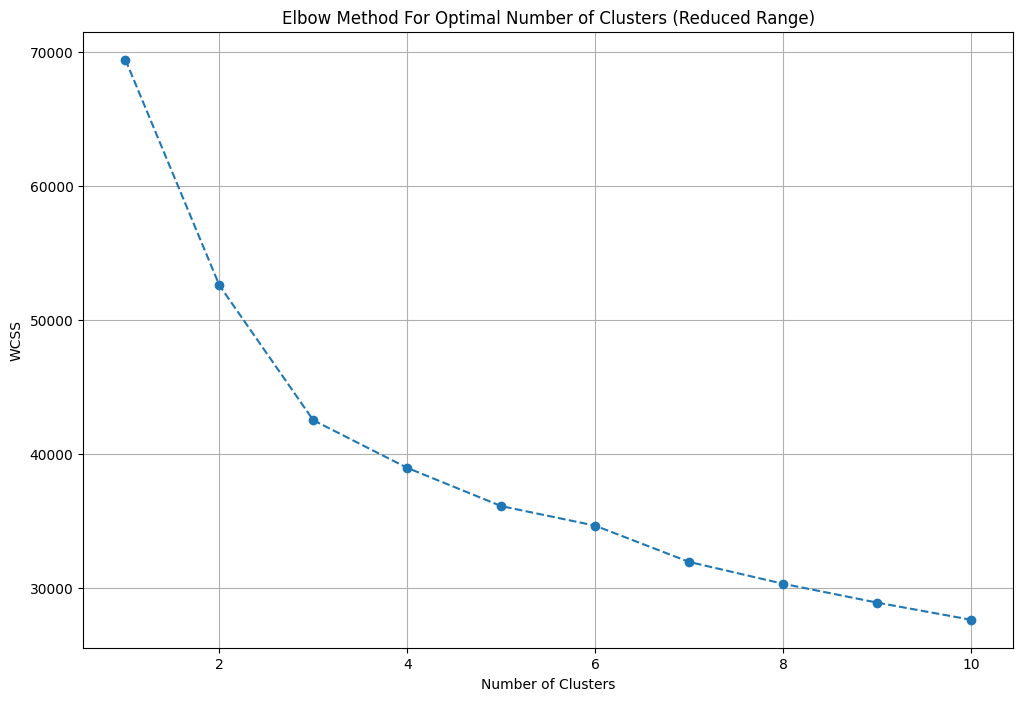

In [45]:
# Plot the Results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [46]:
n_clusters = 3

# Fit the KMeans Model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [47]:
df = df.iloc[:, :-18]

In [48]:
df['furnishing_type'] = cluster_assignments

C:\Users\ACER\AppData\Local\Temp\ipykernel_21140\1695269057.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['furnishing_type'] = cluster_assignments


In [56]:
df.sample(5)[['furnishDetails', 'furnishing_type']]

# 0 -> UnFurnished
# 1 -> SemiFurnished
# 2 -> Furnished

,furnishDetails,furnishing_type
1648,"['5 Fan', '1 Exhaust Fan', '16 Light', '4 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
356,"['2 Wardrobe', '1 Water Purifier', '3 Fan', '2 Geyser', '1 Stove', '8 Light', '2 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine']",0
3168,[],1
1182,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '1 Geyser', '6 Light', '1 TV', '1 Chimney', '1 Curtains', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No Washing Machine', 'No Water Purifier']",0
3754,[],1


### 5. features